In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import os
import pickle

In [2]:
from _utils._utils_spline import eval_spline_basis_equispaced_numeric
from _utils._utils_models import builder_dict

Failed Data


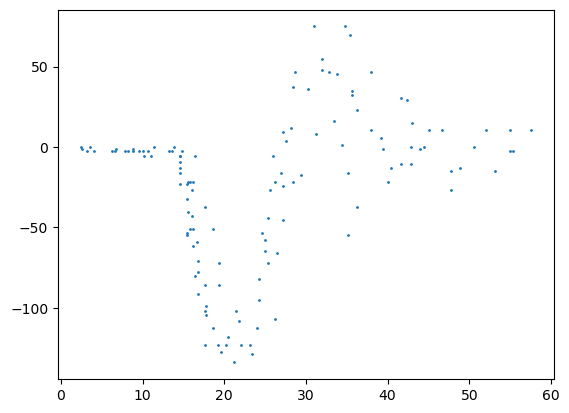

In [6]:
mcycle_data = pd.read_csv("../data/mcycle.csv", index_col=0)
plt.scatter(mcycle_data['times'], mcycle_data['accel'], s=1)

In [3]:
cherry_data = pd.read_csv(os.path.join("../data","cherry_blossoms.csv"), sep=";")
cherry_doi = cherry_data[['year', 'doy']].dropna()

In [16]:
p = 0.05
cherry_doi_sparse_3 = cherry_doi.sample(frac=p, random_state=42).reset_index(drop=True)
#cherry_doi_sparse_3['drop'] = np.random.choice([0, 1], size=len(cherry_doi_sparse_3), p=[p, 1-p])
# cherry_doi_sparse_3 = cherry_doi_sparse_3[cherry_doi_sparse_3['drop'] == 0].drop(columns=['drop'])


In [4]:
cherry_doi_sparse = cherry_doi.copy()
p = 0.2
np.random.seed(42)
cherry_doi_sparse['drop'] = np.random.choice([0, 1], size=len(cherry_doi_sparse), p=[p, 1-p])
cherry_doi_sparse.iloc[-10:, 2] = 0
cherry_doi_sparse.iloc[0:4, 2] = 0
cherry_doi_sparse = cherry_doi_sparse[cherry_doi_sparse['drop'] == 0].drop(columns=['drop'])

In [5]:
cherry_doi_sparse_2 = cherry_doi.copy()
p = 0.2
np.random.seed(42)
cherry_doi_sparse_2['drop'] = np.random.choice([0, 1], size=len(cherry_doi_sparse_2), p=[p, 1-p])
cherry_doi_sparse_2.iloc[-20:, 2] = 0
cherry_doi_sparse_2.iloc[0:4, 2] = 0
cherry_doi_sparse_2 = cherry_doi_sparse_2[cherry_doi_sparse_2['drop'] == 0].drop(columns=['drop'])

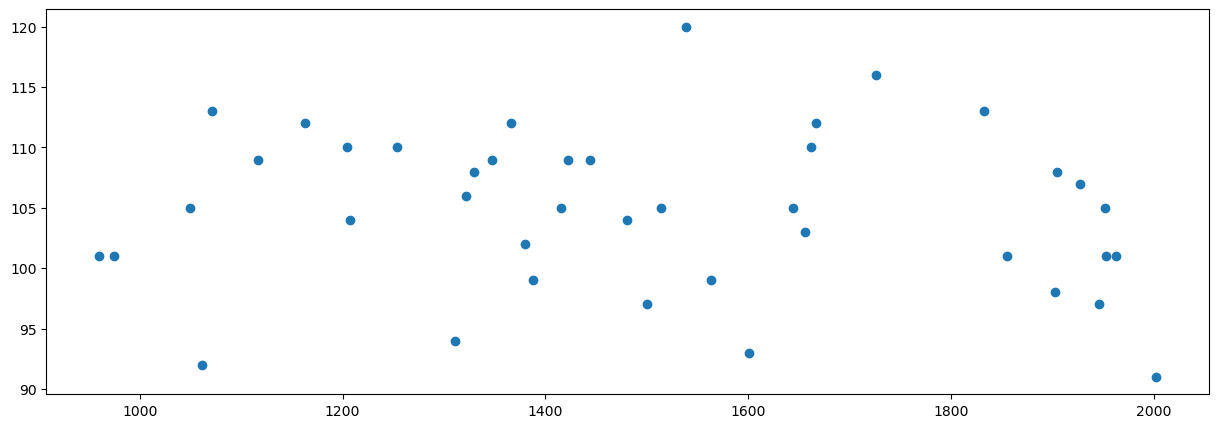

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(cherry_doi_sparse_3['year'], cherry_doi_sparse_3['doy'], 'o', label='data')
plt.show()

In [ ]:
f = f'cherry_doi'
sigma = 0.5
r = [0]

data_pickle = {(f, sigma):{0:(cherry_doi['year'].values, cherry_doi['doy'].values)}}

dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

In [19]:
f = f'cherry_doi_sparse_{p}'
sigma = 0.5
r = [0]

data_pickle = {(f, sigma):{0:(cherry_doi_sparse_3['year'].values, cherry_doi_sparse_3['doy'].values)}}
dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

---

In [72]:
alt_data = cherry_doi_sparse_3.copy()
alt_data.sort_values(by='year', inplace=True)

In [73]:
scale = 5.0
degree = 3
x_vals = alt_data['year'].values
x_vals = np.linspace(np.min(x_vals), np.max(x_vals)+30, 1000).astype(int)

num_knots = 20
B_plot = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_vals)['B']
n, k = B_plot.shape
B_1 = B_plot[:, -1].reshape(-1, 1)
B_1 = B_1/(np.max(B_1) - np.min(B_1))*scale

start_append = -50
step = 5
append = (-B_1*scale+np.mean(alt_data['doy']))[start_append::step]
time_append = x_vals[start_append::step]

alt_data = pd.concat([alt_data[:-1], pd.DataFrame({'year': time_append.flatten(), 'doy': append.flatten()})], ignore_index=True)

In [36]:
alt_data['doy'] -= B_1.flatten()

ValueError: operands could not be broadcast together with shapes (41,) (1000,) 

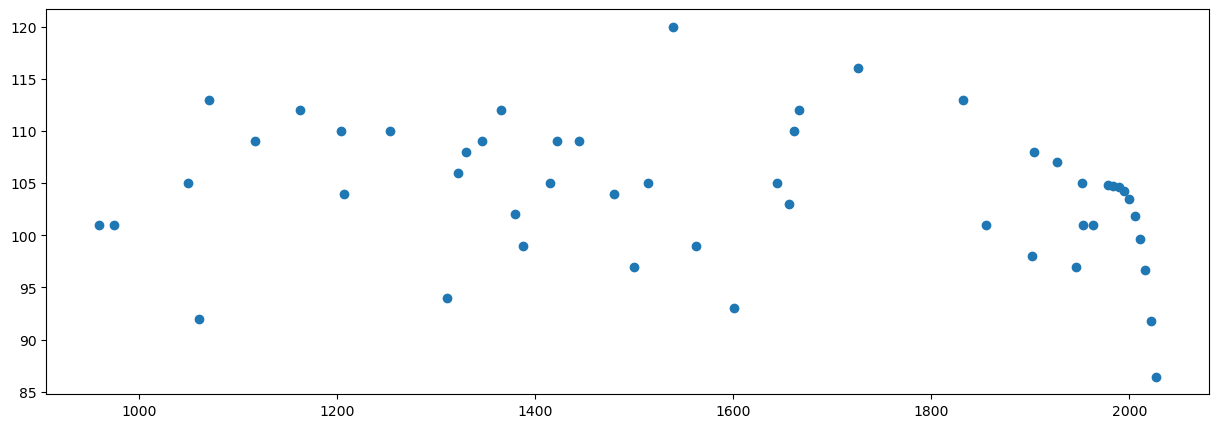

In [74]:
plt.figure(figsize=(15, 5))
plt.plot(alt_data['year'], alt_data['doy'], 'o', label='data')
#plt.plot(x_vals[-50:], append[-50:], 'o', label='data')
plt.show()

In [75]:
f = f'cherry_doi_sparse_{p}_alt_{scale}'
sigma = 0.5
r = [0]

data_pickle = {(f, sigma):{0:(alt_data['year'].values, alt_data['doy'].values)}}
dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

---

In [ ]:
dengue_31003_630_745_k5